# Bus backups and efficiency in Madison, WI
### GEOG 573 Final Project - Alton Hipps

I have been more than once stuck on an overfull and late bus on my way somewhere, and it seems obvious that there is likely to be a spatial pattern related to the area and nearby destinations the bus line travels through as well as the time of day.

I have used the Madison Metro API to collect and collate data into daily csvs for each bus destination. This data includes the time, fullness of the bus, and physical location of the bus at that point. 

The scripts used to collect the data intially are include in the files.This jupyter notebook takes in precollected data, processes and cleans it, combines it into one file (if desired), visualizes the data via keplerGL to create time series maps, and analyzes the data for and understanding of how many and the ratio of empty buses are running. 

The results of this analysis shows at any given time a large portion of buses report being empty; however, there are clear temporal and spatial patterns in where buses are full or half empty. In the mornings and evenings, there are clear effects on bus fullness due to commuters entering and leaving downtown and the UW–Madison campus. For every line, there is also a clear downtime between these commuting peaks.


## Data ingest
#### Import necessary modules

In [180]:
import geopandas as gpd
import pandas as pd
import numpy as np
from osgeo import gdal
import os
from datetime import datetime,timedelta

#!pip install keplerGL
import keplergl

#### Access Data Files and Combine by Bus Route

In [2]:
# Timestamp function
def ts():
    return datetime.now().strftime("%X.%f")

# Short Conditional Print function
def scp(message,boolVal=True):
    if boolVal==True:
        print(f'{ts()}\t{message}')
    else:
        return

#### Define functions to read in data and skip junk lines

In [3]:
def nextReadableLine(fidleObj):
    try:
        csvList=fileObj.readline()
        return csvList
    except:
        return (nextReadableLine(fileObj))

def fileToListOfLists(csvPath):
    fileList=[]
    f=open(csvPath)
    while True:
        line=nextReadableLine(f)
        if not line:
            break
        else:
            lineList=line.split(',')
            fileList.append(lineList)
    f.close()
    return fileList

#### Define class to handle a bus route and create a dataframe for it

In [4]:
# create class to contain data for each bus destination
class BusRoute:
    count=1
    def __init__(self):
        self.id=BusRoute.count
        #self.df=[]
        BusRoute.count+=1

    # Method to read a csv to a dataframe
    def fromCSV(self,csvPath,headDictionary,mode='new'):
        eCount=1
        longList=fileToListOfLists(csvPath)
        # Package as dataframe
        skip=True
        for listItem in longList:
            skip=False
            if len(listItem)!=10:
                skip=True
                continue
            try:
                headDict=dict(headDictionary)
                headDict['TimeStamp'].append(datetime(
                    int(listItem[0][:4]), # year
                    int(listItem[0][4:6]), # month
                    int(listItem[0][6:8]), # day
                    int(listItem[0].split(' ')[1]), # hour
                    int(listItem[0].split(' ')[2]), # minute
                    int(listItem[0].split(' ')[3]) # second
                ))
                headDict['Lat'].append(listItem[1])
                headDict['Long'].append(listItem[2])
                headDict['Heading'].append(listItem[3])
                headDict['RTDesignation'].append(listItem[4])
                headDict['Destination'].append(listItem[5])
                headDict['DelayStatus'].append(listItem[6])
                headDict['Speed'].append(listItem[7])
                headDict['Fullness'].append(listItem[8])
                headDict['BusID'].append(listItem[9][:-1])
            except Exception as e:
                if(len(listItem[0]))>20:listItem='Too long'
                #print(f'{eCount}\t{listItem}')
                #print(f'\t{e}')
                eCount+=1
                continue
        if skip==True:
            #print('No data ingested')
            return False
        if len(headDict)<1:
            #print('No data ingested')
            return False
        outDf=pd.DataFrame(headDict)
        if mode=='new':
            #print('New!!')
            self.df=pd.DataFrame(headDict)
            return True
        elif mode=='add':
            oldDf=self.df
            oldDf.append(outDf)
            self.df=oldDf
            #print('Add!!')
            return True
        else:
            #print('DF Only')
            return outDf

#### Define functions to search folder structure for csvs and to create the BusRoute objects from those csvs

In [5]:
# function to find all csvs
def folderSearch(dataFolder):
    folderStructure=[]
    # Identity Route Name folders
    bigList=os.listdir(dataFolder)
    
    for item in bigList:
        routeList=os.listdir(dataFolder+'\\'+item)
        for route in routeList:
            destinationList=os.listdir(dataFolder+'\\'+item+'\\'+route)
            if len(destinationList)!=0:
                for dest in destinationList:
                    folderStructure.append(dataFolder+'\\'+item+'\\'+route+'\\'+dest)
    return folderStructure

# function to create BusRoute objs for each route
def createBusRoutes(dataFolder,headers):
    busRoutes={}
    counter=0
    allPaths=folderSearch(dataFolder)
    for path in allPaths:
        spliter=path.split('\\')
        routeName=spliter[1]
        destination=spliter[2]
        fileName=spliter[3]

        # add each bus route
        if routeName not in busRoutes.keys():
            busRoutes[routeName]={}

        # add each destination
        routeDict=busRoutes[routeName]
        '''
        if destination not in routeDict.keys():
            routeDict[destination]
        '''
        busObj=BusRoute()
        message=busObj.fromCSV(path,headers)
        if message==True:
            busRoutes[routeName][destination]=busObj.df
        
        ''' for testing
        print(counter)
        counter+=1
        if counter>10:
            break
        '''     
    return busRoutes

#### Define constants to use for this use case

In [6]:
# Constants
headers={
    'TimeStamp':[],
    'Lat':[],
    'Long':[],
    'Heading':[],
    'RTDesignation':[],
    'Destination':[],
    'DelayStatus':[],
    'Speed':[],
    'Fullness':[],
    'BusID':[]
}

folderPath=r"combined"

#### Ingest data to memory
##### Below cell takes a long time to run (up to and over an hour)

In [7]:
dictOfDfs=createBusRoutes(folderPath,headers)

#### Create a large csv of all cleaned data to speed ingest in the future

In [21]:
backup=dictOfDfs.copy()

first=True

for key in dictOfDfs.keys():
    for key2 in dictOfDfs[key].keys():
        #print(key,key2)
        if first==True:
            comboDF=dictOfDfs[key][key2].copy(deep=True)
            #print(comboDF.size)
            first=False
        else:
            comboDF=pd.concat([comboDF,dictOfDfs[key][key2]])
            #print(comboDF.size)

28 INGERSOLL VIA SHERMAN
2810
28 SHERMAN
563840
28 UNIVERSITY ROW VIA SHERMAN
1716570
38 JENIFER
3304140
38 UNIVERSITY ROW
6217030
80 EAGLE HEIGHTS
9137740
80 MEMORIAL UNION
13046540
80 MEMORIAL UNION VIA EAGLE HEIGHTS
18312750
84 EAGLE HEIGHTS
23579150
A 1-SUN PRAIRIE VIA HIGH CROSSING
32643820
A 2-AMERICAN CENTER
43611260
A 2-AMERICAN CENTER VIA HIGH CROSSING
55006200
A AMERICAN CENTER VIA HIGH CROSSING
66416160
A EAST CAMPUS VIA HIGH CROSSING
77840820
A JUNCTION
91883550
A JUNCTION VIA HIGH CROSSING
109813130
A SHEBOYGAN VIA HIGH CROSSING
127751390
B FITCHBURG-CADDIS
146901890
B NORTHPORT
167301900
D 1-SPRECHER
187716860
D 2-MCKEE
208527120
D 2-VERONA ROAD
229360930
D INGERSOLL
250229250
F CAPITOL SQUARE VIA MIDDLETON
272512200
F JUNCTION VIA MIDDLETON
297737600
F MURPHY VIA MIDDLETON
322998590
F SHEBOYGAN VIA MIDDLETON
348949460
R 1-JUNCTION
375048510
R EAST CAMPUS
401161370
R SEGOE
427285520


In [23]:
# Reindex df
comboDF.reset_index()

,index,TimeStamp,Lat,Long,Heading,RTDesignation,Destination,DelayStatus,Speed,Fullness,BusID
0,0,2025-04-09 17:11:05,43.094426725236715,-89.3699367686019,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620
1,1,2025-04-09 17:11:15,43.094426725236715,-89.3699367686019,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620
2,2,2025-04-09 17:12:25,43.09686864909255,-89.36827912041966,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620
3,3,2025-04-09 17:12:36,43.09686864909255,-89.36827912041966,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620
4,4,2025-04-09 17:12:46,43.096990266971694,-89.36813762179273,43,28,INGERSOLL VIA SHERMAN,False,10,EMPTY,61620
...,...,...,...,...,...,...,...,...,...,...,...
42728547,2612410,2025-04-07 17:03:32,43.072830798148985,-89.45914544719909,263,R,SEGOE,False,28,EMPTY,60840
42728548,2612411,2025-04-07 17:03:42,43.07293928566159,-89.46161372138076,274,R,SEGOE,False,26,EMPTY,60840
42728549,2612412,2025-04-07 17:03:52,43.07293928566159,-89.46161372138076,274,R,SEGOE,False,26,EMPTY,60840
42728550,2612413,2025-04-07 17:03:02,43.07297833333334,-89.46390500000001,264,R,SEGOE,False,6,EMPTY,60840


In [24]:
# save to single file if necessary
comboDF.to_csv('AllInOne.csv')

#### Read in full file and clean up extra fields and data

In [7]:
fullPD=pd.read_csv('AllInOne.csv', low_memory=False)
fullPD=fullPD.drop(columns='Unnamed: 0')
fullPD.infer_objects()
filterDf=fullPD[fullPD['Long'].str.contains(r'^(-?\d+)*(\.\d+(\d+)?)?$', regex=True)]
filterDf=filterDf[filterDf['Lat'].str.contains(r'^(-?\d+)*(\.\d+(\d+)?)?$', regex=True)]

filterDf = filterDf.loc[(filterDf['TimeStamp'] >= '2025-03-01')
                     & (filterDf['TimeStamp'] < '2025-04-29')]

filterDf=filterDf.reset_index()

C:\Users\ahipp\AppData\Local\Temp\ipykernel_13228\365445750.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filterDf=fullPD[fullPD['Long'].str.contains(r'^(-?\d+)*(\.\d+(\d+)?)?$', regex=True)]
C:\Users\ahipp\AppData\Local\Temp\ipykernel_13228\365445750.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filterDf=filterDf[filterDf['Lat'].str.contains(r'^(-?\d+)*(\.\d+(\d+)?)?$', regex=True)]


## Data Processing
#### Create geodataframe from lat, long data

In [8]:
gdf = gpd.GeoDataFrame(filterDf,  # convert the dataframe to geodataframe
                            geometry=gpd.points_from_xy(x=filterDf.Long,
                                                        y=filterDf.Lat))

gdf=gdf.drop(['Lat','Long','index'],axis=1)
gdf=gdf.drop_duplicates()

#### Find the largest and smallest date to put bounds on timeslider

In [9]:
maxDate=gdf['TimeStamp'].max()
maxDateObj=datetime(year=int(maxDate[0:4]),month=int(maxDate[5:7]),day=int(maxDate[8:10]))
unixMax = int(str(maxDateObj.timestamp())[:-2]+'00')

minDate=gdf['TimeStamp'].min()
minDateObj=datetime(year=int(minDate[0:4]),month=int(minDate[5:7]),day=int(minDate[8:10]))
unixMin = int(str(minDateObj.timestamp())[:-2]+'00')

dtRange=(unixMin,unixMax)

#### Create specific gdfs for each bus route

In [10]:
filtered_gdf_A = gdf.loc[gdf['RTDesignation'] == 'A'].reset_index().drop(['index'],axis=1)
filtered_gdf_A=filtered_gdf_A.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_B = gdf.loc[gdf['RTDesignation'] == 'B'].reset_index().drop(['index'],axis=1)
filtered_gdf_B=filtered_gdf_B.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_C = gdf.loc[gdf['RTDesignation'] == 'C'].reset_index().drop(['index'],axis=1)
filtered_gdf_C=filtered_gdf_C.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_D = gdf.loc[gdf['RTDesignation'] == 'D'].reset_index().drop(['index'],axis=1)
filtered_gdf_D=filtered_gdf_D.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_F = gdf.loc[gdf['RTDesignation'] == 'F'].reset_index().drop(['index'],axis=1)
filtered_gdf_F=filtered_gdf_F.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_R = gdf.loc[gdf['RTDesignation'] == 'R'].reset_index().drop(['index'],axis=1)
filtered_gdf_R=filtered_gdf_R.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_28 = gdf.loc[gdf['RTDesignation'] == '28'].reset_index().drop(['index'],axis=1)
filtered_gdf_28=filtered_gdf_28.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_38 = gdf.loc[gdf['RTDesignation'] == '38'].reset_index().drop(['index'],axis=1)
filtered_gdf_38=filtered_gdf_38.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_80 = gdf.loc[gdf['RTDesignation'] == '80'].reset_index().drop(['index'],axis=1)
filtered_gdf_80=filtered_gdf_80.iloc[:, [2,3,4,5,6,1,0,7,8]]
filtered_gdf_84 = gdf.loc[gdf['RTDesignation'] == '84'].reset_index().drop(['index'],axis=1)
filtered_gdf_84=filtered_gdf_84.iloc[:, [2,3,4,5,6,1,0,7,8]]

## Visualization
#### Define fuction to create config dictionary/strings for KeplerGL for a given route

In [11]:
def createConfig(rtDes,dateRange):
    outConfig={
        'version': 'v1',
        "config":{
            "visState":{
                "filters":[{
                    "dataId":[f"Rt{rtDes}"],
                    "id":f"Rt{rtDes}_timestamp",
                    "name":["TimeStamp"],
                    "type":"timeRange", 
                    "value":[dateRange[0],dateRange[1]],
                    "plotType":{
                        "interval":"6-hour",
                        "defaultTimeFormat":"L  H A",
                        "type":"histogram",
                        "aggregation":"sum"
                        },
                    "animationWindow":"free",
                    "yAxis":'null',
                    "view":"enlarged",
                    "speed":0.05,
                    "enabled":'true'
                    }
                ],
                "layers":[{
                    "id":f"-Rt{rtDes}_id",
                    "type":"geojson",
                    "config":{
                        "dataId":f"Rt{rtDes}",
                        "columnMode":"geojson",
                        "label":f"Bus Fullness - Route {rtDes}",
                        "color":[34,63,154],
                        "highlightColor":[252,242,26,255],
                        "columns":{"geojson":"geometry"},
                        "isVisible":'true',
                        "visConfig":{
                            "opacity":0.8,
                            "strokeOpacity":0.8,
                            "thickness":0.5,
                            "strokeColor":'null',
                            "colorRange":{
                                "colors":["#FAE300","#CF1750","#223F9A"],
                                "name":"UberPool",
                                "type":"diverging",
                                "category":"Uber",
                                "reversed":True,
                                "colorMap":[["EMPTY","#FAE300"],["FULL","#CF1750"],["HALF_EMPTY","#223F9A"]]
                                },
                            "strokeColorRange":{
                                "name":"Global Warming",
                                "type":"sequential",
                                "category":"Uber",
                                "colors":[
                                    "#4C0035",
                                    "#880030",
                                    "#B72F15",
                                    "#D6610A",
                                    "#EF9100",
                                    "#FFC300"
                                    ]
                                },
                            "radius":10,
                            "sizeRange":[0,10],
                            "radiusRange":[0,50],
                            "heightRange":[0,500],
                            "elevationScale":5,
                            "stroked":False,
                            "filled":True,
                            "enable3d":False,
                            "wireframe":False,
                            "fixedHeight":False
                            },
                        "hidden":False,
                        "textLabel":[{
                            "field":'Fullness',
                            "color":[255,255,255],
                            "size":18,
                            "offset":[0,0],
                            "anchor":"start",
                            "alignment":"center",
                            "outlineWidth":0,
                            "outlineColor":[255,0,0,255],
                            "background":'false',
                            "backgroundColor":[0,0,200,255]
                            }]
                    },
                    "visualChannels":{
                        "colorField":{
                            "name":"Fullness","type":"string"
                        },
                        "colorScale":"customOrdinal",
                        "strokeColorField":'null',
                        "strokeColorScale":"quantile",
                        "sizeField":'null',
                        "sizeScale":"linear",
                        "heightField":'null',
                        "heightScale":"linear",
                        "radiusField":'null',
                        "radiusScale":"linear"
                        }
                }],
                "effects":[],
                "interactionConfig":{
                    "tooltip":{
                        "fieldsToShow":{
                            "-RtA_id":[{
                                    "name":"DelayStatus",
                                    "format":'null'
                                },{
                                    "name":"Destination",
                                    "format":'null'
                                },{
                                    "name":"Fullness",
                                    "format":'null'
                                },{
                                    "name":"Speed",
                                    "format":'null'
                                }]
                        },
                        "compareMode":False,
                        "compareType":"absolute",
                        "enabled":True
                    },
                    "brush":{
                        "size":0.5,
                        "enabled":False
                    },
                    "geocoder":{
                        "enabled":False
                    },
                    "coordinate":{
                        "enabled":False
                    }
                },
                "layerBlending":"additive",
                "overlayBlending":"screen",
                "splitMaps":[],
                "animationConfig":{
                    "currentTime":'null',
                    "speed":1
                },
                "editor":{
                    "features":[],
                    "visible":False
                }
            },
            "mapState":{
                "bearing":0,
                "dragRotate":False,
                "latitude":43.07794042346403,
                "longitude":-89.37636850809596,
                "pitch":20,
                "zoom":11,
                "isSplit":False,
                "isViewportSynced":True,
                "isZoomLocked":False,
                "splitMapViewports":[]
            },'''
            "mapStyle":{
                "styleType":"dark-matter",
                "topLayerGroups":{},
                "visibleLayerGroups":{
                    "label":True,
                    "road":True,
                    "border":False,
                    "building":True,
                    "water":True,
                    "land":True,
                    "3d building":False
                },
                "threeDBuildingColor":[15.035172933000911,15.035172933000911,15.035172933000911],
                "backgroundColor":[0,0,0],
                "mapStyles":{}
            },'''
            "uiState":{
                "mapControls":{
                    "mapLegend":{
                        "active":True
                    }
                }
            }
        }
    }
    return outConfig

#### Create map for the route A
##### Additional filtering necessary to reduce final file size

In [12]:
# if too many points, filter for the most recent 1.5 million
maxRecCount=5000000

if filtered_gdf_A.shape[0]>maxRecCount:
    filtered_gdf_A=filtered_gdf_A.sort_values(by='TimeStamp',ascending=False).reset_index()
    filtered_gdf_A=filtered_gdf_A.drop(['index'],axis=1)
    filtered_gdf_A=filtered_gdf_A.loc[0:maxRecCount-1]
    try:
        filtered_gdf_A=filtered_gdf_A.drop(['level_0'], axis=1)
    except:
        pass
filtered_gdf_A.shape

(1241367, 9)

In [13]:
%%time

map_A = keplergl.KeplerGl(config=createConfig('A',dtRange), show_docs=False)
map_A.add_data(data=filtered_gdf_A, name='RtA')

map_A.save_to_html(file_name='route/A.html',read_only=True)

Map saved to route/A.html!
CPU times: total: 26.1 s
Wall time: 26.3 s


#### Create map for the route B

In [82]:
%%time

map_B = keplergl.KeplerGl(config=createConfig('B',dtRange), show_docs=False)
map_B.add_data(data=filtered_gdf_B, name='RtB')

map_B.save_to_html(file_name='route/B.html',read_only=True)

Map saved to route/B.html!
CPU times: total: 9.73 s
Wall time: 4.95 s


#### Create map for the route C

In [83]:
%%time

map_C = keplergl.KeplerGl(config=createConfig('C',dtRange), show_docs=False)
map_C.add_data(data=filtered_gdf_C, name='RtC')

map_C.save_to_html(file_name='route/C.html',read_only=True)

Map saved to route/C.html!
CPU times: total: 250 ms
Wall time: 116 ms


#### Create map for the route D

In [84]:
%%time

map_D = keplergl.KeplerGl(config=createConfig('D',dtRange), show_docs=False)
map_D.add_data(data=filtered_gdf_D, name='RtD')

map_D.save_to_html(file_name='route/D.html',read_only=True)

Map saved to route/D.html!
CPU times: total: 3.28 s
Wall time: 1.67 s


#### Create map for the route F

In [85]:
%%time

map_F = keplergl.KeplerGl(config=createConfig('F',dtRange), show_docs=False)
map_F.add_data(data=filtered_gdf_F, name='RtF')

map_F.save_to_html(file_name='route/F.html',read_only=True)

Map saved to route/F.html!
CPU times: total: 19.1 s
Wall time: 9.66 s


#### Create map for the route R

In [86]:
%%time

map_R = keplergl.KeplerGl(config=createConfig('R',dtRange), show_docs=False)
map_R.add_data(data=filtered_gdf_R, name='RtR')

map_R.save_to_html(file_name='route/R.html',read_only=True)

Map saved to route/R.html!
CPU times: total: 734 ms
Wall time: 369 ms


#### Create 28 map

In [87]:
%%time

map_28 = keplergl.KeplerGl(config=createConfig('28',dtRange), show_docs=False)
map_28.add_data(data=filtered_gdf_28, name='Rt28')

map_28.save_to_html(file_name='route/28.html',read_only=True)

Map saved to route/28.html!
CPU times: total: 4.66 s
Wall time: 2.36 s


#### Create 38 map

In [88]:
%%time

map_38 = keplergl.KeplerGl(config=createConfig('38',dtRange), show_docs=False)
map_38.add_data(data=filtered_gdf_38, name='Rt38')

map_38.save_to_html(file_name='route/38.html',read_only=True)

Map saved to route/38.html!
CPU times: total: 7.11 s
Wall time: 3.62 s


#### Create 80 map

In [89]:
%%time

map_80 = keplergl.KeplerGl(config=createConfig('80',dtRange), show_docs=False)
map_80.add_data(data=filtered_gdf_80, name='Rt80')

map_80.save_to_html(file_name='route/80.html',read_only=True)

Map saved to route/80.html!
CPU times: total: 10.1 s
Wall time: 5.22 s


#### Create 84 map (terrible data for some reason)

In [90]:
%%time

map_84 = keplergl.KeplerGl(config=createConfig('84',dtRange), show_docs=False)
map_84.add_data(data=filtered_gdf_84, name='Rt84')

map_84.save_to_html(file_name='route/84.html',read_only=True)

Map saved to route/84.html!
CPU times: total: 0 ns
Wall time: 5.21 ms


### Create graphs
#### Clean up extra columns if there

In [181]:
#gdf=gdf.reset_index()
try:
    gdf=gdf.drop(['index'],axis=1)
    gdf=gdf.drop(['level_0'],axis=1)
except:
    pass

gdf

,TimeStamp,Heading,RTDesignation,Destination,DelayStatus,Speed,Fullness,BusID,geometry
0,2025-04-09 17:11:05,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620,POINT (-89.36994 43.09443)
1,2025-04-09 17:11:15,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620,POINT (-89.36994 43.09443)
2,2025-04-09 17:12:25,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620,POINT (-89.36828 43.09687)
3,2025-04-09 17:12:36,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620,POINT (-89.36828 43.09687)
4,2025-04-09 17:12:46,43,28,INGERSOLL VIA SHERMAN,False,10,EMPTY,61620,POINT (-89.36814 43.09699)
...,...,...,...,...,...,...,...,...,...
2606912,2025-04-07 17:03:32,263,R,SEGOE,False,28,EMPTY,60840,POINT (-89.45915 43.07283)
2606913,2025-04-07 17:03:42,274,R,SEGOE,False,26,EMPTY,60840,POINT (-89.46161 43.07294)
2606914,2025-04-07 17:03:52,274,R,SEGOE,False,26,EMPTY,60840,POINT (-89.46161 43.07294)
2606915,2025-04-07 17:03:02,264,R,SEGOE,False,6,EMPTY,60840,POINT (-89.46391 43.07298)


#### Add an hour column to a copy of the df 

In [182]:
gdf_time=gdf.copy(deep=True)
gdf_time['Time']=pd.to_datetime(gdf_time['TimeStamp'])
gdf_time['Time']=gdf_time['Time'].dt.hour
gdf_time

,TimeStamp,Heading,RTDesignation,Destination,DelayStatus,Speed,Fullness,BusID,geometry,Time
0,2025-04-09 17:11:05,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620,POINT (-89.36994 43.09443),17
1,2025-04-09 17:11:15,61,28,INGERSOLL VIA SHERMAN,False,26,EMPTY,61620,POINT (-89.36994 43.09443),17
2,2025-04-09 17:12:25,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620,POINT (-89.36828 43.09687),17
3,2025-04-09 17:12:36,19,28,INGERSOLL VIA SHERMAN,False,16,EMPTY,61620,POINT (-89.36828 43.09687),17
4,2025-04-09 17:12:46,43,28,INGERSOLL VIA SHERMAN,False,10,EMPTY,61620,POINT (-89.36814 43.09699),17
...,...,...,...,...,...,...,...,...,...,...
2606912,2025-04-07 17:03:32,263,R,SEGOE,False,28,EMPTY,60840,POINT (-89.45915 43.07283),17
2606913,2025-04-07 17:03:42,274,R,SEGOE,False,26,EMPTY,60840,POINT (-89.46161 43.07294),17
2606914,2025-04-07 17:03:52,274,R,SEGOE,False,26,EMPTY,60840,POINT (-89.46161 43.07294),17
2606915,2025-04-07 17:03:02,264,R,SEGOE,False,6,EMPTY,60840,POINT (-89.46391 43.07298),17


#### Create a new df of counts of fullness responses by hour by line

In [183]:
gdf_full=gdf_time.loc[gdf['Fullness']=='FULL'].reset_index().drop(['index'],axis=1)
gdf_halfEmpty=gdf_time.loc[gdf['Fullness']=='HALF_EMPTY'].reset_index().drop(['index'],axis=1)


hourRange=gdf_time['Time'].unique()
hourRange.sort()
routeList=gdf_time['RTDesignation'].unique()
values=['EMPTY','HALF_EMPTY','FULL']

colNames=[]
for route in routeList:
    for value in values:
        colNames.append(f'{route}_{value}')
#print(colNames)

freqDf=pd.DataFrame(index=hourRange,columns=colNames)
#print(newDf.shape)

for hour in hourRange:
    sliced=gdf_time.loc[gdf_time['Time']==hour]
    for route in routeList:
        newSlice=sliced.loc[sliced['RTDesignation']==route]
        for value in values:
            counts=newSlice.loc[newSlice['Fullness']==value].shape[0]
            #print(f'{hour}:\t{route}:\t{value}:\t{counts}')
            colString=f'{route}_{value}'
            #print(colString,counts)
            freqDf.at[hour,colString]=counts

freqDf

,28_EMPTY,28_HALF_EMPTY,28_FULL,38_EMPTY,38_HALF_EMPTY,38_FULL,80_EMPTY,80_HALF_EMPTY,80_FULL,84_EMPTY,...,B_FULL,F_EMPTY,F_HALF_EMPTY,F_FULL,R_EMPTY,R_HALF_EMPTY,R_FULL,nan_EMPTY,nan_HALF_EMPTY,nan_FULL
0,0,0,0,0,0,0,1439,0,0,0,...,0,0,0,0,84,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,197,0,0,0,0,0,0,...,0,3298,0,0,233,0,0,0,0,0
6,4255,947,0,5562,18,0,5308,0,0,0,...,0,22975,421,0,645,0,0,0,0,0
7,7877,2408,155,11701,2722,302,13908,855,44,0,...,0,28260,2013,0,746,0,0,0,0,0
8,8131,2650,260,10473,3247,401,13045,2616,111,0,...,0,28089,2187,134,2068,34,0,0,0,0
9,7788,2705,358,12128,2353,418,14434,4044,959,0,...,0,29019,2035,247,894,0,0,0,0,0
10,9617,1333,441,12158,1376,671,14847,3688,702,0,...,0,30042,1077,22,747,0,0,0,0,0
11,10075,1215,226,13781,1164,204,14884,2784,614,0,...,35,31879,693,0,679,33,0,0,0,0
12,9634,1580,280,13025,1287,367,15440,4002,747,0,...,0,29611,1247,0,963,4,0,0,0,0


#### Create a dict of routes with the column names they correspond to

In [184]:
columns=freqDf.columns
routeToColDict={}
for col in columns:
    rt=col.split('_')[0]
    if rt in routeToColDict.keys():
        colList=routeToColDict[rt]
        colList.append(col)
        routeToColDict[rt]=colList
    else:
        routeToColDict[rt]=[col]

routeToColDict

{'28': ['28_EMPTY', '28_HALF_EMPTY', '28_FULL'],
 '38': ['38_EMPTY', '38_HALF_EMPTY', '38_FULL'],
 '80': ['80_EMPTY', '80_HALF_EMPTY', '80_FULL'],
 '84': ['84_EMPTY', '84_HALF_EMPTY', '84_FULL'],
 'A': ['A_EMPTY', 'A_HALF_EMPTY', 'A_FULL'],
 'C': ['C_EMPTY', 'C_HALF_EMPTY', 'C_FULL'],
 'D': ['D_EMPTY', 'D_HALF_EMPTY', 'D_FULL'],
 'B': ['B_EMPTY', 'B_HALF_EMPTY', 'B_FULL'],
 'F': ['F_EMPTY', 'F_HALF_EMPTY', 'F_FULL'],
 'R': ['R_EMPTY', 'R_HALF_EMPTY', 'R_FULL'],
 'nan': ['nan_EMPTY', 'nan_HALF_EMPTY', 'nan_FULL']}

#### Create a dictionary of dfs for each line via slices of the full df

In [185]:
dfDict={}

for route in routeToColDict.keys():
    if route=='nan':continue
    rtList=routeToColDict[route]
    tempDf=pd.DataFrame(index=hourRange)
    for colName in rtList:
        value=colName.split('_')
        tempDf[value[1]]=freqDf[colName]
        dfDict[route]=tempDf
dfDict

{'28':     EMPTY  HALF FULL
 0       0     0    0
 4       0     0    0
 5       0     0    0
 6    4255   947    0
 7    7877  2408  155
 8    8131  2650  260
 9    7788  2705  358
 10   9617  1333  441
 11  10075  1215  226
 12   9634  1580  280
 13  10237  1143  139
 14   8061  1267  305
 15   5220   946  278
 16   5921  1269  600
 17   5805  1136  614
 18    251     7    0
 19      0     0    0
 20      0     0    0
 21      0     0    0
 22      0     0    0
 23      0     0    0,
 '38':     EMPTY  HALF FULL
 0       0     0    0
 4       0     0    0
 5     197     0    0
 6    5562    18    0
 7   11701  2722  302
 8   10473  3247  401
 9   12128  2353  418
 10  12158  1376  671
 11  13781  1164  204
 12  13025  1287  367
 13  14462   894   40
 14  12302  1262  474
 15  13184  2160  123
 16  15454  3454    8
 17  13476  3359  140
 18   1090   358    0
 19      0     0    0
 20      0     0    0
 21      0     0    0
 22      0     0    0
 23      0     0    0,
 '80':     EMPTY  

#### Create plot objs for each bus line of the frequency of each each fullness response over the hours of a day

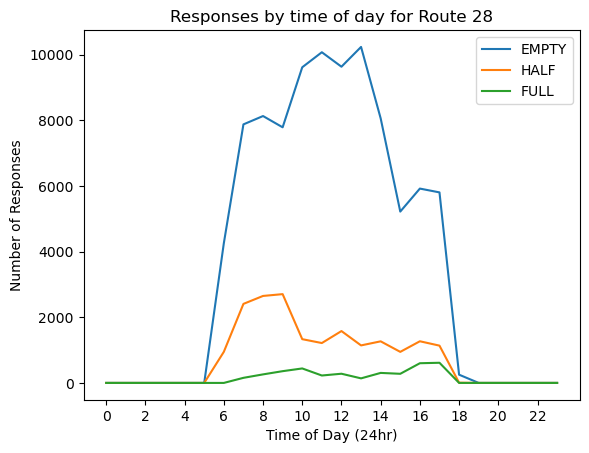

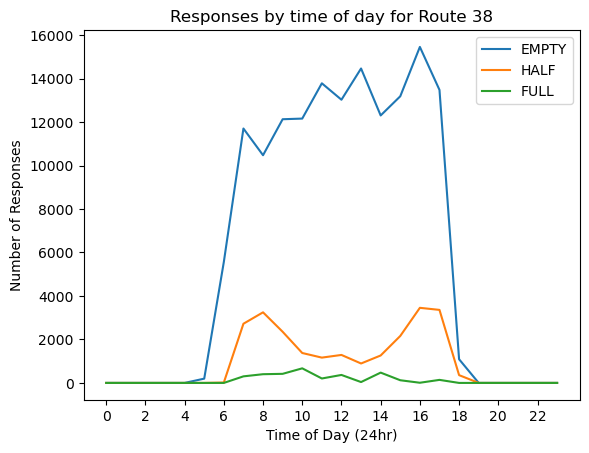

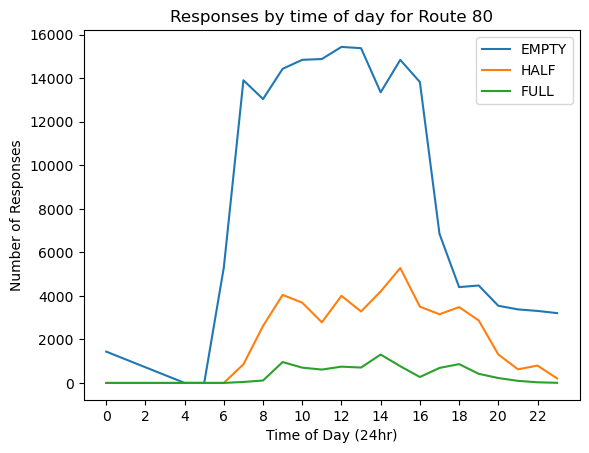

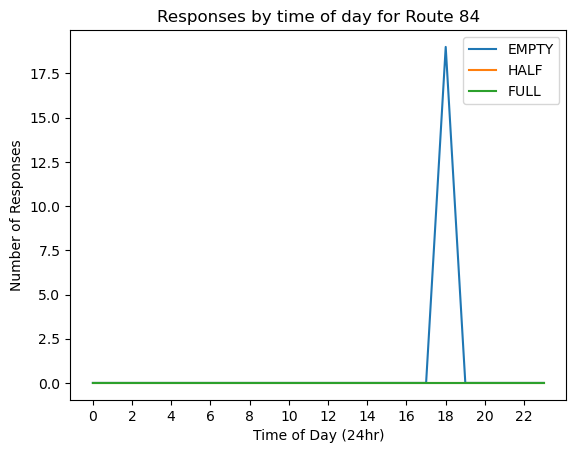

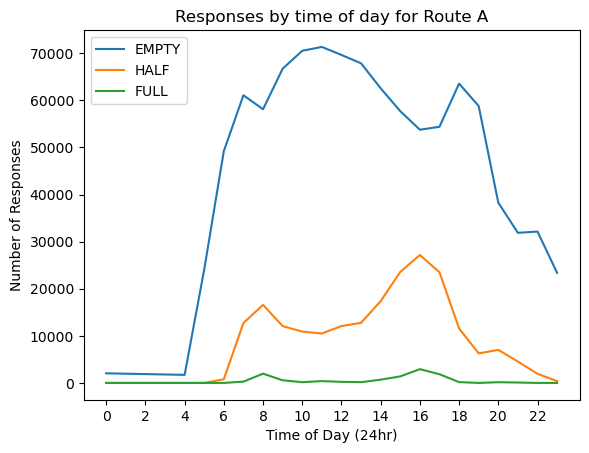

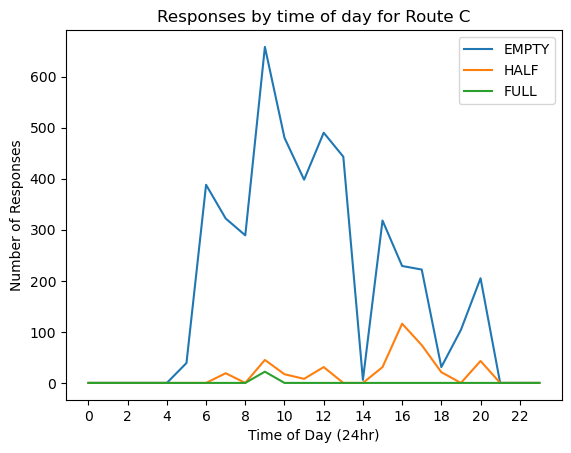

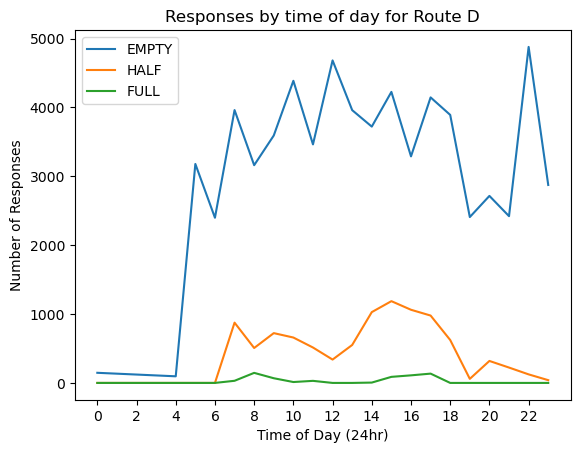

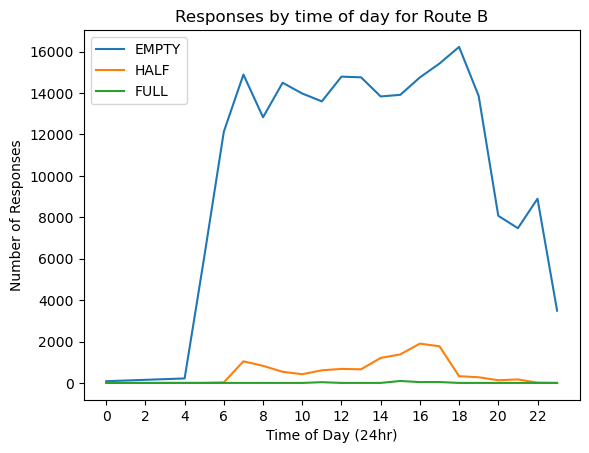

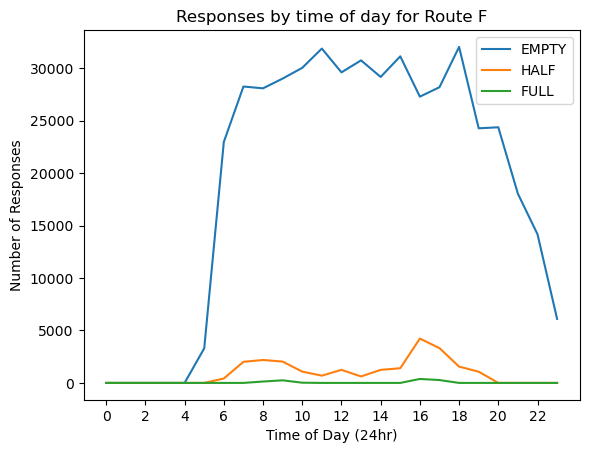

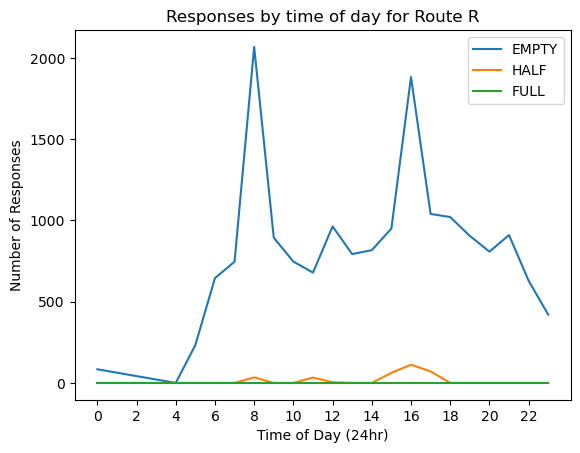

In [186]:
x_axis=[0,2,4,6,8,10,12,14,16,18,20,22]

for route in dfDict.keys():    
    plot=dfDict[route].plot(xlabel='Time of Day (24hr)',
                      ylabel='Number of Responses',
                      xticks=x_axis,
                      title=f'Responses by time of day for Route {route}')
    plt=plot.figure
    plt.savefig(f'figures/{route}_ResponsesOverTime.jpg',bbox_inches='tight', dpi=300)

#### Calculate ratio of fullness responses for each line and hour

In [191]:
ratiosDf=pd.DataFrame(index=hourRange)

for route in dfDict.keys():
    currentRouteDf=dfDict[route]
    currentRouteDf['Top']=currentRouteDf['FULL']+currentRouteDf['HALF']
    currentRouteDf['Bottom']=currentRouteDf['EMPTY']+currentRouteDf['HALF']+currentRouteDf['FULL']
    currentRouteDf['Bottom']=currentRouteDf['Bottom'].replace(0, np.nan)
    currentRouteDf['Ratio']=currentRouteDf['Top']/currentRouteDf['Bottom']
    currentRouteDf=currentRouteDf.drop(['Bottom'], axis=1)
    currentRouteDf=currentRouteDf.drop(['Top'], axis=1)
    ratiosDf[route]=currentRouteDf['Ratio']
    currentRouteDf=currentRouteDf.drop(['Ratio'], axis=1)

ratiosDf

C:\Users\ahipp\AppData\Local\Temp\ipykernel_13228\2636279108.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  currentRouteDf['Bottom']=currentRouteDf['Bottom'].replace(0, np.nan)
C:\Users\ahipp\AppData\Local\Temp\ipykernel_13228\2636279108.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  currentRouteDf['Bottom']=currentRouteDf['Bottom'].replace(0, np.nan)
C:\Users\ahipp\AppData\Local\Temp\ipykernel_13228\2636279108.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. T

,28,38,80,84,A,C,D,B,F,R
0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,0.0,NaN,0.0
4,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN
5,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
6,0.182045,0.003226,0.0,NaN,0.015601,0.0,0.0,0.002139,0.017995,0.0
7,0.245498,0.205365,0.060715,NaN,0.175441,0.055718,0.186152,0.065462,0.066495,0.0
8,0.263563,0.258339,0.172901,NaN,0.241926,0.0,0.171211,0.060417,0.076324,0.016175
9,0.282278,0.185986,0.257396,NaN,0.15918,0.092414,0.18047,0.035726,0.072905,0.0
10,0.155737,0.144104,0.228206,NaN,0.135559,0.034205,0.132859,0.029244,0.035291,0.0
11,0.12513,0.090303,0.185866,NaN,0.13243,0.019704,0.135762,0.045225,0.021276,0.046348
12,0.161824,0.112678,0.235227,NaN,0.150153,0.059501,0.067516,0.043712,0.040411,0.004137


#### Plot ratios against each other

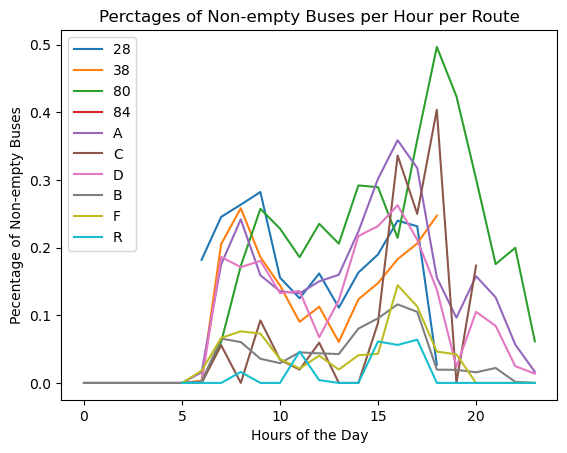

In [194]:
plot=ratiosDf.plot(title='Perctages of Non-empty Buses per Hour per Route',
              ylabel='Pecentage of Non-empty Buses',
             xlabel='Hours of the Day')
plt=plot.figure
plt.savefig(f'figures/Percentage.jpg',bbox_inches='tight', dpi=300)